In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.metrics import roc_curve, auc, precision_recall_curve

# 1. Define the file path and load the data
results_dir = "../02_Processed_Data/07_Model_Results"
csv_path = os.path.join(results_dir, "LOOCV_Predictions_Results.csv")

# Load the predictions dataframe
df_results = pd.read_csv(csv_path)

# Extract true labels and probabilities for global metrics
y_true_all = df_results['True_Class'].values
y_prob_all = df_results['Probability'].values

print(f"✅ Data loaded successfully! Total samples: {len(df_results)}")

✅ Data loaded successfully! Total samples: 25307


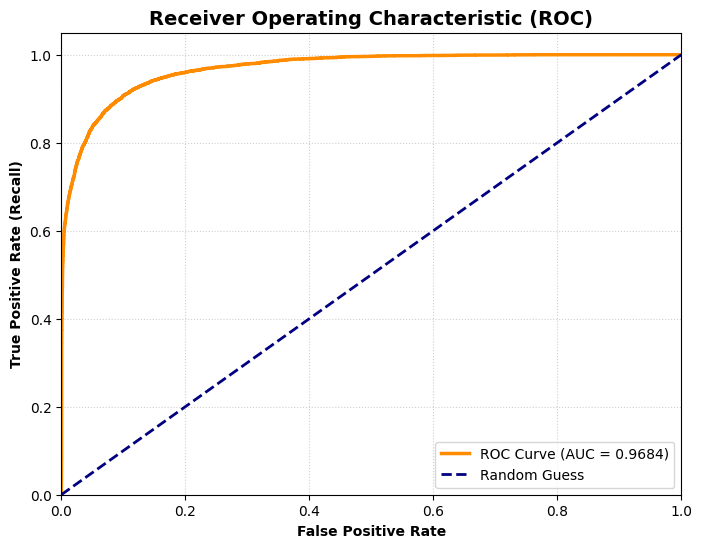

In [2]:
# Calculate False Positive Rate, True Positive Rate and Thresholds
fpr, tpr, roc_thresholds = roc_curve(y_true_all, y_prob_all)
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2.5, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontweight='bold')
plt.ylabel('True Positive Rate (Recall)', fontweight='bold')
plt.title('Receiver Operating Characteristic (ROC)', fontweight='bold', fontsize=14)
plt.legend(loc="lower right")
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

Optimal Threshold: 0.4965
Maximum F1 Score: 0.8577


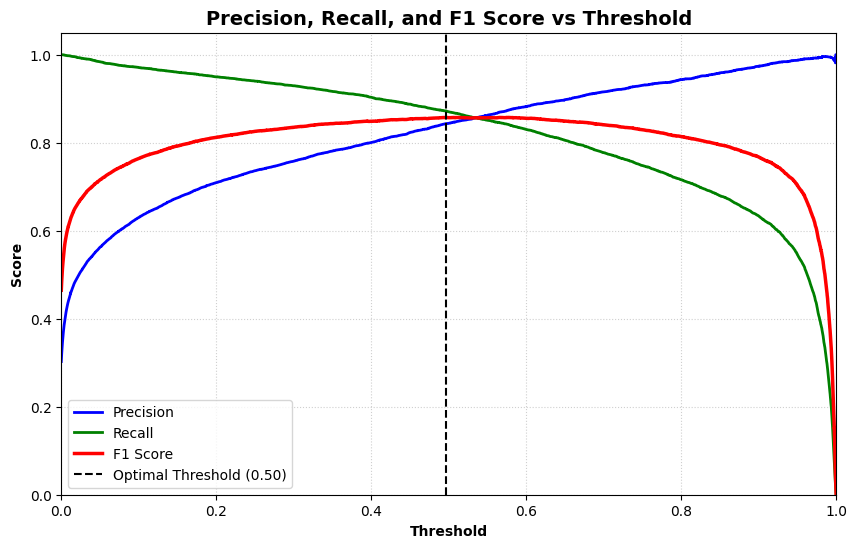

In [3]:
# Calculate Precision, Recall and Thresholds
precision, recall, pr_thresholds = precision_recall_curve(y_true_all, y_prob_all)

# Calculate F1 Score for each threshold (adding small epsilon to avoid division by zero)
f1_scores = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-10)

# Find the threshold that maximizes F1 Score
best_idx = np.argmax(f1_scores)
optimal_threshold = pr_thresholds[best_idx]
best_f1 = f1_scores[best_idx]

print(f"Optimal Threshold: {optimal_threshold:.4f}")
print(f"Maximum F1 Score: {best_f1:.4f}")

# Plot Precision-Recall vs Thresholds
plt.figure(figsize=(10, 6))
plt.plot(pr_thresholds, precision[:-1], 'b-', label='Precision', linewidth=2)
plt.plot(pr_thresholds, recall[:-1], 'g-', label='Recall', linewidth=2)
plt.plot(pr_thresholds, f1_scores, 'r-', label='F1 Score', linewidth=2.5)

# Add vertical line for optimal threshold
plt.axvline(x=optimal_threshold, color='black', linestyle='--', 
            label=f'Optimal Threshold ({optimal_threshold:.2f})')

plt.xlabel('Threshold', fontweight='bold')
plt.ylabel('Score', fontweight='bold')
plt.title('Precision, Recall, and F1 Score vs Threshold', fontweight='bold', fontsize=14)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.legend(loc='best')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

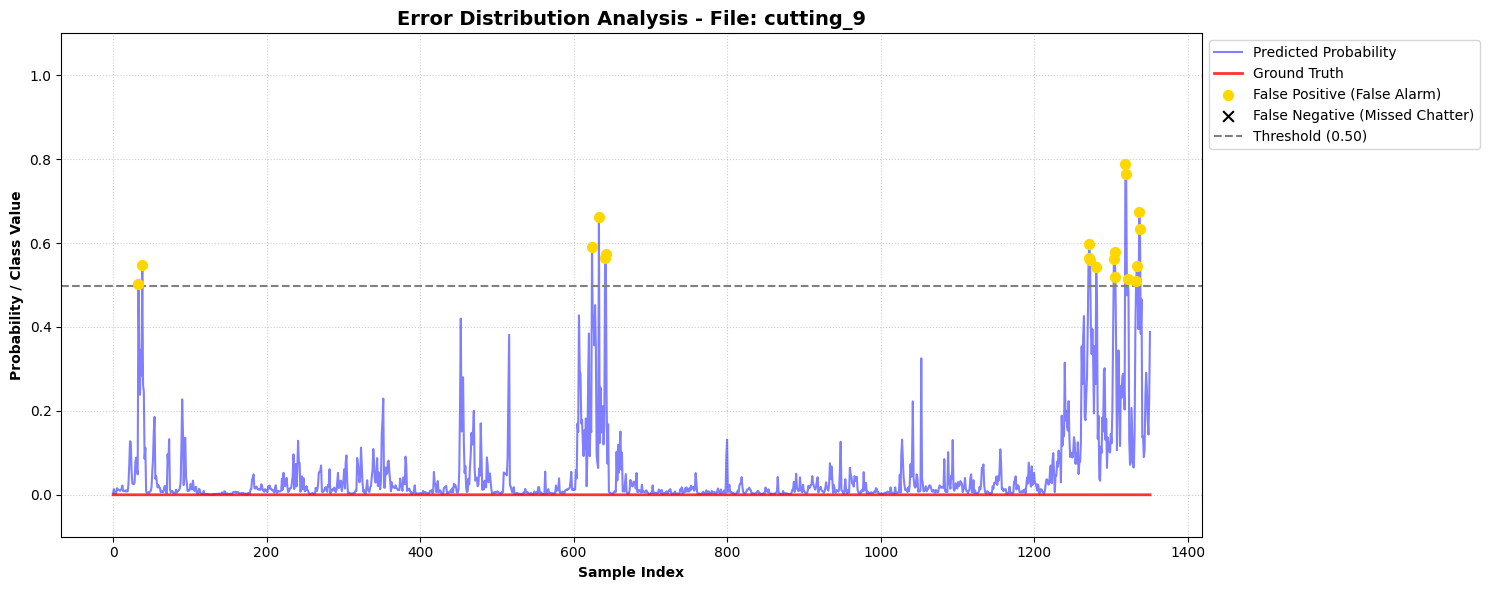

In [4]:
# Select a specific file to analyze
unique_files = df_results['File_ID'].unique()
file_id_to_plot = unique_files[3] # Taking the first file as an example

# Filter data for this specific file
file_data = df_results[df_results['File_ID'] == file_id_to_plot].reset_index(drop=True)

# Calculate predictions based on the OPTIMAL threshold found above (or you can force 0.5)
current_threshold = optimal_threshold 
file_data['Opt_Prediction'] = (file_data['Probability'] >= current_threshold).astype(int)

# Identify Errors
# False Positives: Model says 1, but True is 0
fp_mask = (file_data['Opt_Prediction'] == 1) & (file_data['True_Class'] == 0)
# False Negatives: Model says 0, but True is 1
fn_mask = (file_data['Opt_Prediction'] == 0) & (file_data['True_Class'] == 1)

# Plot
plt.figure(figsize=(15, 6))

# Plot True Class and Probability
plt.plot(file_data.index, file_data['Probability'], color='blue', alpha=0.5, label='Predicted Probability')
plt.plot(file_data.index, file_data['True_Class'], color='red', linewidth=2, alpha=0.8, label='Ground Truth')

# Highlight Errors
plt.scatter(file_data.index[fp_mask], file_data['Probability'][fp_mask], 
            color='gold', marker='o', s=50, label='False Positive (False Alarm)', zorder=5)
plt.scatter(file_data.index[fn_mask], file_data['Probability'][fn_mask], 
            color='black', marker='x', s=60, label='False Negative (Missed Chatter)', zorder=5)

plt.axhline(y=current_threshold, color='gray', linestyle='--', 
            label=f'Threshold ({current_threshold:.2f})')

plt.title(f"Error Distribution Analysis - File: {file_id_to_plot}", fontweight='bold', fontsize=14)
plt.xlabel("Sample Index", fontweight='bold')
plt.ylabel("Probability / Class Value", fontweight='bold')
plt.ylim(-0.1, 1.1)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()